In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

In [2]:
df = pd.read_csv("cleaned_data/sodic.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date').sort_index()

In [3]:
df.shape

(2753, 6)

In [4]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2753 entries, 2015-01-04 to 2026-04-30
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   price       2753 non-null   float64
 1   open        2753 non-null   float64
 2   high        2753 non-null   float64
 3   low         2753 non-null   float64
 4   vol         810 non-null    float64
 5   change_pct  2753 non-null   float64
dtypes: float64(6)
memory usage: 150.6 KB


In [6]:
df.head()

,price,open,high,low,vol,change_pct
date,,,,,,
2015-01-04,14.41,14.49,14.54,14.23,NaN,0.07
2015-01-05,14.38,14.30,14.53,14.26,NaN,-0.21
2015-01-06,13.92,14.03,14.10,13.80,NaN,-3.20
2015-01-08,14.12,14.10,14.25,13.97,NaN,1.44
2015-01-11,13.97,14.01,14.18,13.85,NaN,-1.06


In [7]:
df.tail()

,price,open,high,low,vol,change_pct
date,,,,,,
2026-04-26,21.81,22.38,22.43,21.70,2.02,-1.31
2026-04-27,21.76,22.14,22.20,21.63,1.42,-0.23
2026-04-28,21.92,21.72,22.49,21.72,2.67,0.74
2026-04-29,21.90,21.93,22.21,21.80,1.15,-0.09
2026-04-30,21.71,22.00,22.30,21.56,2.02,-0.87


In [8]:
#print null count
print(df.isnull().sum())

price            0
open             0
high             0
low              0
vol           1943
change_pct       0
dtype: int64


In [9]:
#drop vol column
df.drop(columns="vol", inplace=True)

In [10]:
#Computing daily % return 
df['return'] = df['price'].pct_change() * 100 

In [11]:
#Adding lag features
df['return_lag1'] = df['return'].shift(1)
df['return_lag2'] = df['return'].shift(2)

In [12]:
#Adding rolling features
df['ma_20']         = df['price'].rolling(20).mean()
df['volatility_20'] = df['return'].rolling(20).std()
df['ma_5']          = df['price'].rolling(5).mean()

In [13]:
df['dist_to_ma5'] = (df['price'] / df['ma_5']) - 1
df['dist_to_ma20'] = (df['price'] / df['ma_20']) - 1

In [14]:
# 1. Calculate the Fast (12-day) and Slow (26-day) Exponential Moving Averages (EMA)
ema_12 = df['price'].ewm(span=12, adjust=False).mean()
ema_26 = df['price'].ewm(span=26, adjust=False).mean()

# 2. Calculate the raw MACD line
df['macd'] = ema_12 - ema_26

# 3. Calculate the Signal Line (9-day EMA of the MACD)
df['macd_signal'] = df['macd'].ewm(span=9, adjust=False).mean()

# 4. Calculate the MACD Histogram (The most useful feature for ML)
# This represents the distance between the MACD and its signal line
df['macd_hist'] = df['macd'] - df['macd_signal']

# What this does: A rising macd_hist means short-term momentum is accelerating upward.

In [15]:
# 1. Calculate the 20-day SMA (Middle Band) and 20-day Standard Deviation
window = 20
sma_20 = df['price'].rolling(window=window).mean()
std_20 = df['price'].rolling(window=window).std()

# 2. Calculate Upper and Lower Bands
upper_band = sma_20 + (std_20 * 2)
lower_band = sma_20 - (std_20 * 2)

# 3. Feature A: Bollinger %B (Where is price relative to the bands?)
# Value of 1.0 = price is touching upper band. Value of 0.0 = touching lower band.
df['bb_pb'] = (df['price'] - lower_band) / (upper_band - lower_band)

# 4. Feature B: Bollinger Bandwidth (How volatile is the market right now?)
# Useful for detecting "squeezes" before explosive moves.
df['bb_bandwidth'] = (upper_band - lower_band) / sma_20

In [16]:
#Adding RSI
delta = df['price'].diff()
gain  = delta.clip(lower=0).rolling(14).mean()
loss  = (-delta.clip(upper=0)).rolling(14).mean()
df['rsi'] = 100 - (100 / (1 + gain / loss))

In [17]:
threshold = 0.005

future_return = df['return'].shift(-1)

df['label'] = (future_return > threshold).astype(int)

In [18]:
#Adding rolling features adds NaN rows
df = df.dropna()

In [19]:
df.drop(columns=['price', 'ma_5', 'ma_20'], inplace=True)

In [20]:
# Note for modeling team: price, ma_5, ma_20 are in EGP price scale
# while return, rsi etc. are percentages. Please apply StandardScaler or MinMaxScaler before training.
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2733 entries, 2015-02-03 to 2026-04-30
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   open           2733 non-null   float64
 1   high           2733 non-null   float64
 2   low            2733 non-null   float64
 3   change_pct     2733 non-null   float64
 4   return         2733 non-null   float64
 5   return_lag1    2733 non-null   float64
 6   return_lag2    2733 non-null   float64
 7   volatility_20  2733 non-null   float64
 8   dist_to_ma5    2733 non-null   float64
 9   dist_to_ma20   2733 non-null   float64
 10  macd           2733 non-null   float64
 11  macd_signal    2733 non-null   float64
 12  macd_hist      2733 non-null   float64
 13  bb_pb          2733 non-null   float64
 14  bb_bandwidth   2733 non-null   float64
 15  rsi            2733 non-null   float64
 16  label          2733 non-null   int64  
dtypes: float64(16), int64(1)
memory usage: 384.3 

In [21]:
df.head()

,open,high,low,change_pct,return,return_lag1,return_lag2,volatility_20,dist_to_ma5,dist_to_ma20,macd,macd_signal,macd_hist,bb_pb,bb_bandwidth,rsi,label
date,,,,,,,,,,,,,,,,,
2015-02-03,15.24,15.60,15.24,1.65,1.646904,-0.524246,-0.844704,1.515993,0.004034,0.030006,0.262276,0.254893,0.007383,0.691541,0.156654,68.421053,1
2015-02-04,15.42,15.76,15.36,1.10,1.101750,1.646904,-0.524246,1.518745,0.014832,0.037131,0.269335,0.257781,0.011554,0.738926,0.155407,70.124481,0
2015-02-05,15.40,15.42,15.20,-2.12,-2.115385,1.101750,1.646904,1.397376,-0.005082,0.010656,0.245472,0.255319,-0.009848,0.576997,0.138393,59.459459,0
2015-02-08,15.27,15.43,15.05,-0.33,-0.327439,-2.115385,1.101750,1.389002,-0.007823,0.003693,0.219989,0.248253,-0.028264,0.529899,0.123513,53.974895,0
2015-02-09,15.04,15.20,14.95,-1.18,-1.182654,-0.327439,-2.115385,1.395845,-0.017764,-0.011664,0.183158,0.235234,-0.052076,0.382245,0.099055,45.531915,0


In [22]:
df.tail()

,open,high,low,change_pct,return,return_lag1,return_lag2,volatility_20,dist_to_ma5,dist_to_ma20,macd,macd_signal,macd_hist,bb_pb,bb_bandwidth,rsi,label
date,,,,,,,,,,,,,,,,,
2026-04-26,22.38,22.43,21.70,-1.31,-1.312217,-0.896861,-2.192982,2.529748,-0.009267,0.063487,0.825974,0.660790,0.165183,0.810439,0.204509,68.411867,0
2026-04-27,22.14,22.20,21.63,-0.23,-0.229253,-1.312217,-0.896861,2.464663,-0.017785,0.054723,0.807169,0.690066,0.117103,0.770451,0.202341,66.546763,1
2026-04-28,21.72,22.49,21.72,0.74,0.735294,-0.229253,-1.312217,2.453008,-0.002639,0.056589,0.796001,0.711253,0.084748,0.778717,0.203034,67.600701,0
2026-04-29,21.93,22.21,21.80,-0.09,-0.091241,0.735294,-0.229253,2.457635,0.000091,0.050108,0.776584,0.724319,0.052265,0.747848,0.202172,66.184448,0
2026-04-30,22.00,22.30,21.56,-0.87,-0.867580,-0.091241,0.735294,2.475027,-0.005041,0.036549,0.737365,0.726928,0.010437,0.682877,0.199856,69.980880,0


In [23]:
#return is the same as change_pct so we can drop change_pct
print((df['return'].round(2) == df['change_pct'].round(2)).value_counts())

True     2729
False       4
Name: count, dtype: int64


In [24]:
df.drop(columns=['open', 'high', 'low', 'change_pct'], inplace=True)

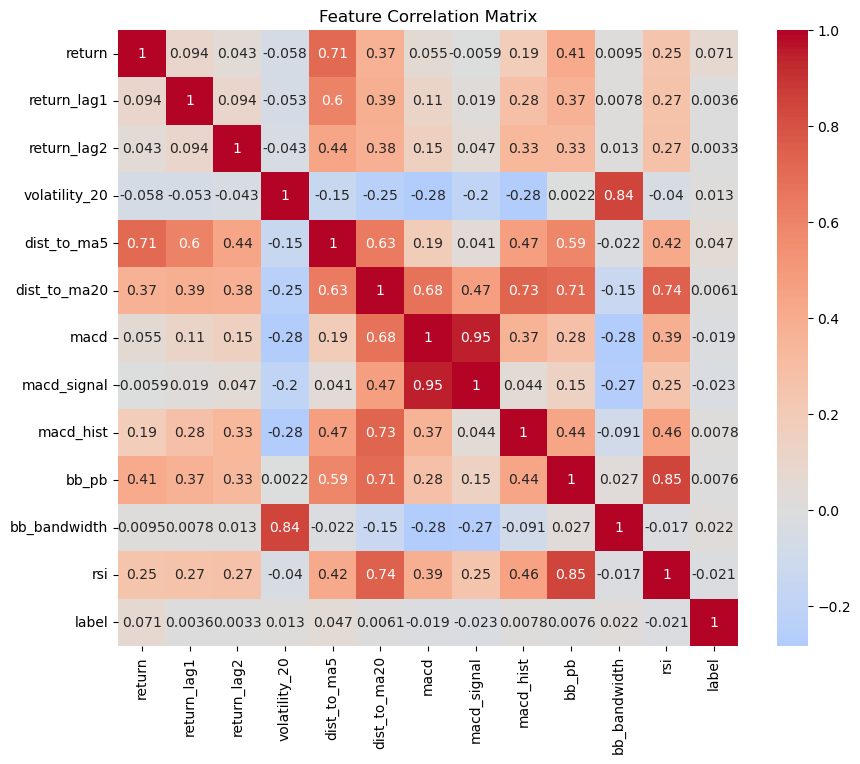

In [25]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0)

plt.title('Feature Correlation Matrix')
plt.show()

In [26]:
df.corr()

,return,return_lag1,return_lag2,volatility_20,dist_to_ma5,dist_to_ma20,macd,macd_signal,macd_hist,bb_pb,bb_bandwidth,rsi,label
return,1.000000,0.094349,0.042930,-0.057523,0.714551,0.373381,0.054841,-0.005869,0.186119,0.408669,0.009500,0.251567,0.071409
return_lag1,0.094349,1.000000,0.094364,-0.052524,0.604581,0.385243,0.108611,0.018659,0.281520,0.373434,0.007847,0.267389,0.003563
return_lag2,0.042930,0.094364,1.000000,-0.042649,0.443162,0.379470,0.150942,0.047315,0.329750,0.326499,0.012949,0.269558,0.003299
volatility_20,-0.057523,-0.052524,-0.042649,1.000000,-0.149585,-0.247048,-0.278410,-0.200364,-0.282995,0.002218,0.842586,-0.040103,0.012898
dist_to_ma5,0.714551,0.604581,0.443162,-0.149585,1.000000,0.634961,0.191106,0.040651,0.472860,0.589081,-0.021733,0.418794,0.047178
dist_to_ma20,0.373381,0.385243,0.379470,-0.247048,0.634961,1.000000,0.678191,0.473554,0.731123,0.708373,-0.146706,0.740310,0.006065
macd,0.054841,0.108611,0.150942,-0.278410,0.191106,0.678191,1.000000,0.946152,0.365175,0.280598,-0.278998,0.385341,-0.019370
macd_signal,-0.005869,0.018659,0.047315,-0.200364,0.040651,0.473554,0.946152,1.000000,0.044146,0.147321,-0.267717,0.254864,-0.023489
macd_hist,0.186119,0.281520,0.329750,-0.282995,0.472860,0.731123,0.365175,0.044146,1.000000,0.442286,-0.091119,0.456264,0.007769
bb_pb,0.408669,0.373434,0.326499,0.002218,0.589081,0.708373,0.280598,0.147321,0.442286,1.000000,0.026844,0.845717,0.007587


In [27]:
df.drop(columns=['dist_to_ma20', 'macd', 'macd_signal', 'volatility_20'], inplace=True)

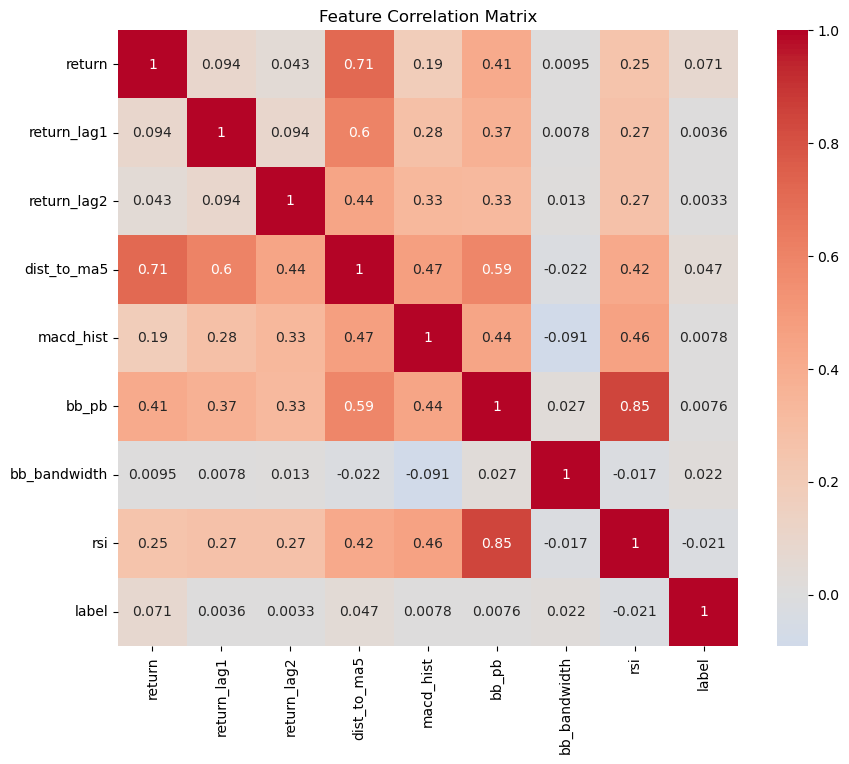

In [28]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0)

plt.title('Feature Correlation Matrix')
plt.show()

In [29]:
df.corr()

,return,return_lag1,return_lag2,dist_to_ma5,macd_hist,bb_pb,bb_bandwidth,rsi,label
return,1.000000,0.094349,0.042930,0.714551,0.186119,0.408669,0.009500,0.251567,0.071409
return_lag1,0.094349,1.000000,0.094364,0.604581,0.281520,0.373434,0.007847,0.267389,0.003563
return_lag2,0.042930,0.094364,1.000000,0.443162,0.329750,0.326499,0.012949,0.269558,0.003299
dist_to_ma5,0.714551,0.604581,0.443162,1.000000,0.472860,0.589081,-0.021733,0.418794,0.047178
macd_hist,0.186119,0.281520,0.329750,0.472860,1.000000,0.442286,-0.091119,0.456264,0.007769
bb_pb,0.408669,0.373434,0.326499,0.589081,0.442286,1.000000,0.026844,0.845717,0.007587
bb_bandwidth,0.009500,0.007847,0.012949,-0.021733,-0.091119,0.026844,1.000000,-0.017043,0.022248
rsi,0.251567,0.267389,0.269558,0.418794,0.456264,0.845717,-0.017043,1.000000,-0.020854
label,0.071409,0.003563,0.003299,0.047178,0.007769,0.007587,0.022248,-0.020854,1.000000


In [30]:
sns.set_theme(style="darkgrid", palette="muted")

C:\Users\moata\AppData\Local\Temp\ipykernel_28120\2791296911.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='label', palette=['#ff6b6b', '#1dd1a1'])


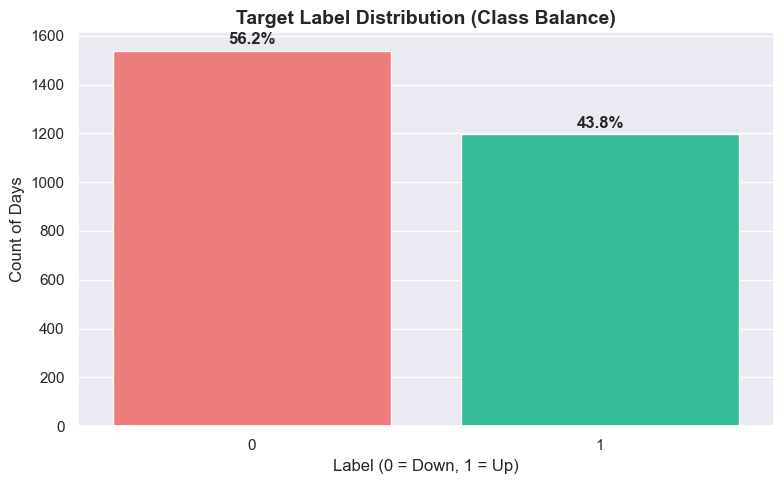

In [31]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='label', palette=['#ff6b6b', '#1dd1a1'])

# Add title and labels
plt.title("Target Label Distribution (Class Balance)", fontsize=14, fontweight='bold')
plt.xlabel("Label (0 = Down, 1 = Up)", fontsize=12)
plt.ylabel("Count of Days", fontsize=12)

# Calculate and add percentage text on top of the bars
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height() + (total * 0.01) # slight offset above bar
    ax.annotate(percentage, (x, y), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

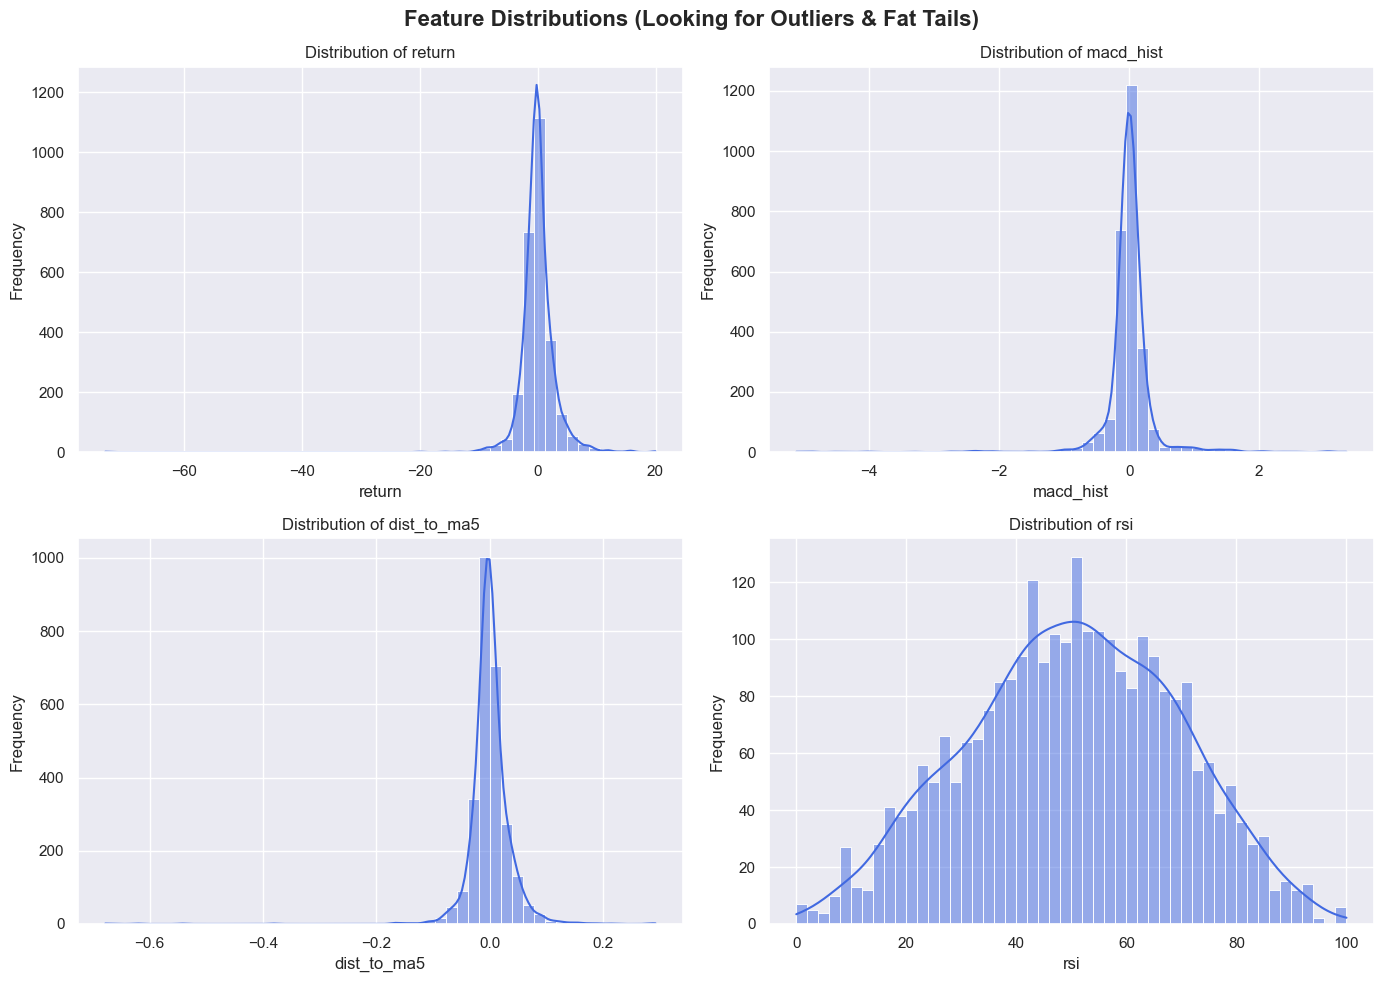

In [32]:
features_to_plot = ['return', 'macd_hist', 'dist_to_ma5', 'rsi']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Feature Distributions (Looking for Outliers & Fat Tails)", fontsize=16, fontweight='bold')

# Flatten axes for easy looping
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    sns.histplot(df[feature], kde=True, ax=axes[i], color='royalblue', bins=50)
    axes[i].set_title(f"Distribution of {feature}")
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

C:\Users\moata\AppData\Local\Temp\ipykernel_28120\1749860680.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='label', y=feature, ax=axes[i], palette=['#ff6b6b', '#1dd1a1'])
C:\Users\moata\AppData\Local\Temp\ipykernel_28120\1749860680.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='label', y=feature, ax=axes[i], palette=['#ff6b6b', '#1dd1a1'])
C:\Users\moata\AppData\Local\Temp\ipykernel_28120\1749860680.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='label', y=feature, ax=axes[i], pal

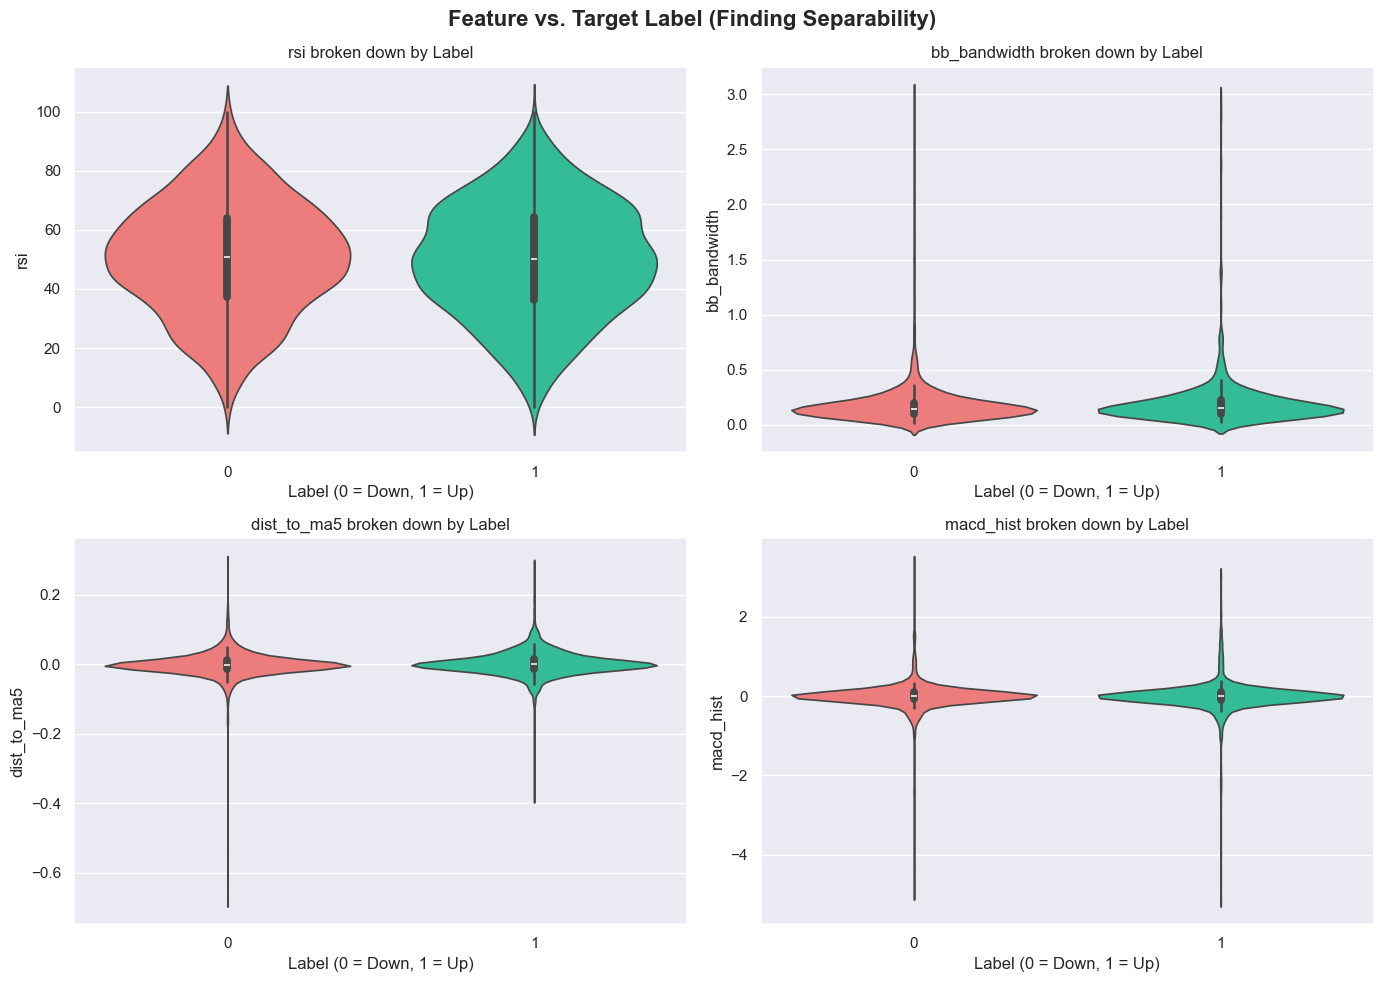

In [33]:
features_to_plot = ['rsi', 'bb_bandwidth', 'dist_to_ma5', 'macd_hist']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Feature vs. Target Label (Finding Separability)", fontsize=16, fontweight='bold')

axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    # Violin plot splits the distribution by the label
    sns.violinplot(data=df, x='label', y=feature, ax=axes[i], palette=['#ff6b6b', '#1dd1a1'])
    axes[i].set_title(f"{feature} broken down by Label")
    axes[i].set_xlabel("Label (0 = Down, 1 = Up)")

plt.tight_layout()
plt.show()

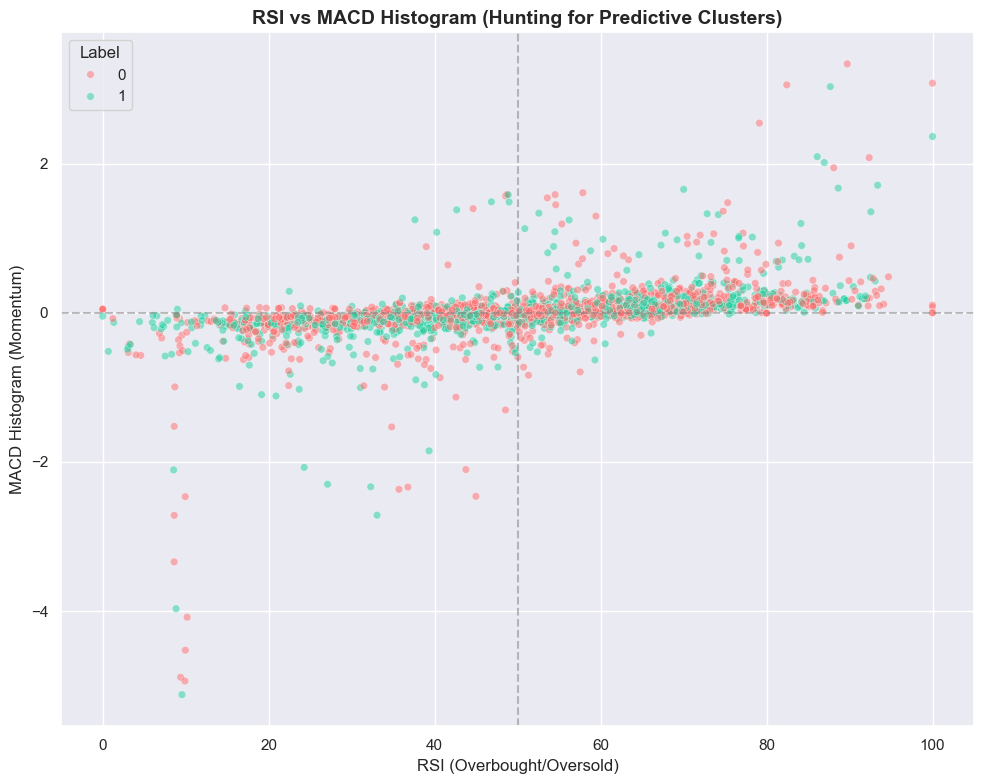

In [34]:
plt.figure(figsize=(10, 8))

# Scatter plot: X is RSI (momentum), Y is MACD (trend), colored by the label
sns.scatterplot(
    data=df, 
    x='rsi', 
    y='macd_hist', 
    hue='label', 
    palette=['#ff6b6b', '#1dd1a1'], # Red for 0, Green for 1
    alpha=0.5, # Makes overlapping dots transparent
    s=30       # Size of dots
)

plt.title("RSI vs MACD Histogram (Hunting for Predictive Clusters)", fontsize=14, fontweight='bold')
plt.xlabel("RSI (Overbought/Oversold)", fontsize=12)
plt.ylabel("MACD Histogram (Momentum)", fontsize=12)
plt.axvline(50, color='gray', linestyle='--', alpha=0.5) # RSI midpoint
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)  # MACD midpoint

plt.legend(title='Label')
plt.tight_layout()
plt.show()

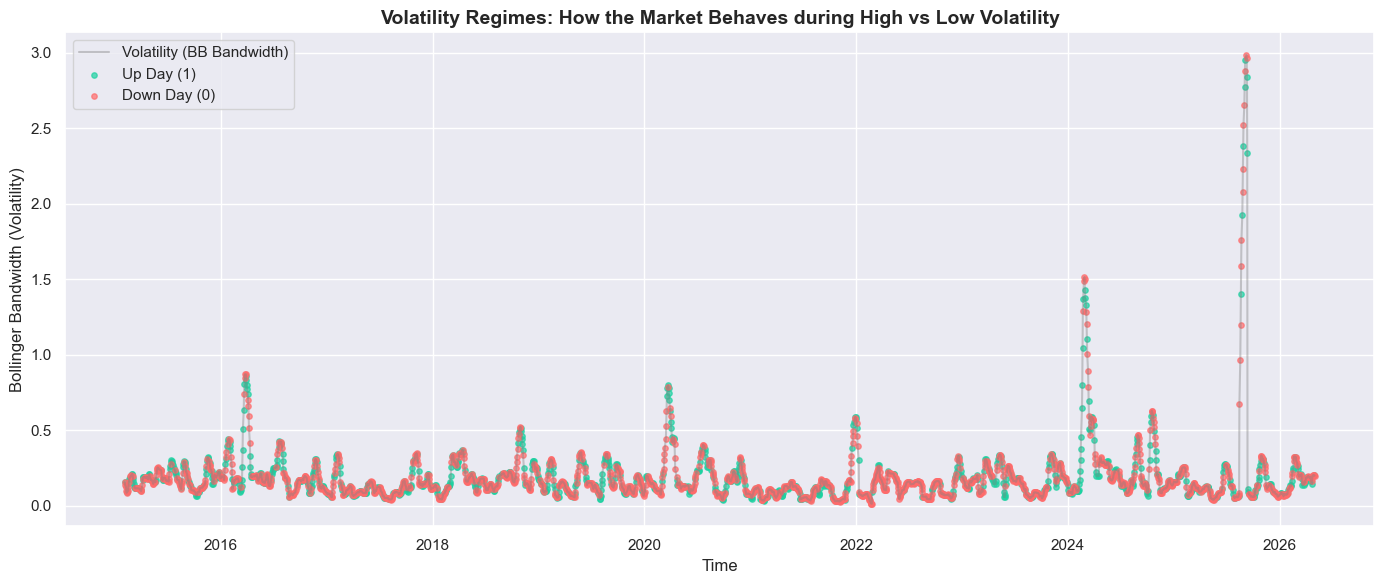

In [35]:
plt.figure(figsize=(14, 6))

# Plot the baseline volatility as a gray line
plt.plot(df.index, df['bb_bandwidth'], color='gray', alpha=0.4, label='Volatility (BB Bandwidth)')

# Overlay Green dots for Up days (Label 1)
up_days = df[df['label'] == 1]
plt.scatter(up_days.index, up_days['bb_bandwidth'], color='#1dd1a1', s=15, alpha=0.7, label='Up Day (1)')

# Overlay Red dots for Down days (Label 0)
down_days = df[df['label'] == 0]
plt.scatter(down_days.index, down_days['bb_bandwidth'], color='#ff6b6b', s=15, alpha=0.7, label='Down Day (0)')

plt.title("Volatility Regimes: How the Market Behaves during High vs Low Volatility", fontsize=14, fontweight='bold')
plt.xlabel("Time", fontsize=12)
plt.ylabel("Bollinger Bandwidth (Volatility)", fontsize=12)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [36]:
df.to_csv('final_data/final_sodic.csv')